In [ ]:
#Qué hace: describe el tiempo hasta alcanzar RCS desde T₀.
#Clave: introduce censura y horizonte de seguimiento (a explicitar).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
COHORT_PATH  = "04_cohorte_base_T0.parquet"
RCS_PATH     = "10_respuesta_clinica_sostenida.parquet"
OUT_PARQUET  = "12_duracion_antibiotico_hasta_RCS.parquet"

KEYS = ["subject_id", "hadm_id", "icu_stay_id"]

In [2]:
# -----------------------------
# 1) Load data
# -----------------------------
df_base = pd.read_parquet(COHORT_PATH)
df_rcs  = pd.read_parquet(RCS_PATH)

In [3]:
# -----------------------------
# 2) Collapse baseline to 1 row per stay
# -----------------------------
df_base = (
    df_base
    .sort_values(KEYS + ["t0_antibiotic"])
    .drop_duplicates(KEYS, keep="first")
)

In [4]:
# -----------------------------
# 3) Keep only stays with RCS
# -----------------------------
df_rcs = df_rcs[df_rcs["ever_rcs"] == 1].copy()

In [5]:
# -----------------------------
# 4) Merge
# -----------------------------
df = df_base.merge(
    df_rcs[KEYS + ["rcs_day_idx"]],
    on=KEYS,
    how="inner"
)

In [6]:
# -----------------------------
# 5) Duration of antibiotic until RCS
# -----------------------------
df["days_since_t0_until_rcs"] = df["rcs_day_idx"] + 1

# Sanity checks
assert df["days_since_t0_until_rcs"].min() >= 1

In [7]:
# -----------------------------
# 6) Descriptive statistics
# -----------------------------
desc = df["days_since_t0_until_rcs"].describe(
    percentiles=[0.25, 0.5, 0.75]
)

print("\nDuration of antibiotic until RCS (days):")
print(desc)

print("\nProportion reaching RCS before standard durations:")
for d in [3, 5, 7, 10, 14]:
    print(
        f"≤ {d} days:",
        (df["days_since_t0_until_rcs"] <= d).mean()
    )


Duration of antibiotic until RCS (days):
count    35743.000000
mean         6.086199
std          6.211895
min          2.000000
25%          2.000000
50%          3.000000
75%          8.000000
max         29.000000
Name: days_since_t0_until_rcs, dtype: float64

Proportion reaching RCS before standard durations:
≤ 3 days: 0.5561648434658535
≤ 5 days: 0.6725232912738158
≤ 7 days: 0.7425509890048401
≤ 10 days: 0.8088017234143748
≤ 14 days: 0.8764233556220798


In [8]:
# -----------------------------
# 7) Save dataset
# -----------------------------
df.to_parquet(OUT_PARQUET, index=False)
print("\nSaved:", OUT_PARQUET)


Saved: 12_duracion_antibiotico_hasta_RCS.parquet


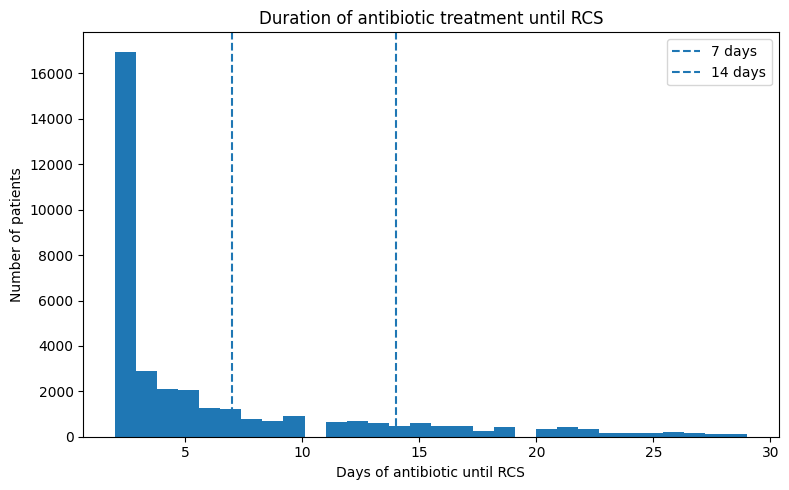

In [9]:
# -----------------------------
# 8) Simple plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df["days_since_t0_until_rcs"], bins=30)
plt.axvline(7, linestyle="--", label="7 days")
plt.axvline(14, linestyle="--", label="14 days")
plt.xlabel("Days of antibiotic until RCS")
plt.ylabel("Number of patients")
plt.title("Duration of antibiotic treatment until RCS")
plt.legend()
plt.tight_layout()
plt.show()